In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from tqdm.auto import tqdm

# Helper functions, colors, etc

In [2]:
def open_dfs(path):
    """Open and concatenate all dataframes in directory."""
    df_list = [pd.read_parquet(f) for f in tqdm(sorted(glob.glob(f"data/{path}/*.pq")), desc=path)]
    return pd.concat(df_list, axis="index")

In [3]:
def penalty(df, grouping_key):
    """Compute flight distance penalty."""
    return df.groupby(grouping_key)[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
        lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum()
    )

In [4]:
def hit_rate(df, grouping_key):
    """Compute hit rate."""
    return df.groupby(grouping_key)[
        ["observed_pcr_area_in_forecast_pcr", "observed_pcr_area"]
    ].apply(lambda x: x["observed_pcr_area_in_forecast_pcr"].sum() / x["observed_pcr_area"].sum())

In [5]:
def jackknife(df, resampling_key, statistic):
    """Compute jacknife statistics."""
    groups = df.groupby(resampling_key)
    keys = groups.keys.unique()
    indices = groups.indices

    jn_list = []
    for drop in tqdm(keys, desc="jackknife"):
        idx = np.concatenate([indices[key] for key in keys if key != drop])
        subset = df.iloc[idx]
        jn_list.append(statistic(subset))

    jn = pd.concat(jn_list, axis="columns")
    return jn

In [6]:
def bootstrap(df, resampling_key, num_iterations, statistic, alpha, rng):
    """Compute bootstrap confidence intervals."""
    groups = df.groupby(resampling_key)
    keys = groups.keys.unique()
    indices = groups.indices

    theta_star_list = []
    for i in tqdm(range(num_iterations), desc="bootstrap"):
        samples = rng.choice(keys, keys.size, replace=True)
        idx = np.concatenate([indices[key] for key in samples])
        resampled = df.iloc[idx]
        theta_star_list.append(statistic(resampled))

    theta_star = pd.concat(theta_star_list, axis="columns")
    theta = statistic(df)
    z0 = (theta_star < theta.values.reshape((-1, 1))).mean(axis="columns").map(norm.ppf)
    jn = jackknife(df, resampling_key, statistic)
    jn_bar = np.mean(jn.values, axis=1, keepdims=True)
    a = ((jn - jn_bar) ** 3).sum(axis="columns") / (
        6.0 * ((jn - jn_bar) ** 2).sum(axis="columns") ** 1.5
    )

    z1 = norm.ppf(alpha / 2.0)
    z2 = norm.ppf(1.0 - alpha / 2.0)
    q1 = (z0 + (z0 + z1) / (1.0 - a * (z0 + z1))).apply(norm.cdf)
    q2 = (z0 + (z0 + z2) / (1.0 - a * (z0 + z2))).apply(norm.cdf)

    return theta_star.apply(
        lambda x: x.quantile([q1.loc[x.name], q2.loc[x.name]]).reset_index(drop=True),
        axis="columns",
    )

In [7]:
exo_black = "#161a26"
tropo_blue = "#1093ff"
solar_orange = "#f26400"
gray50 = "#939598"

# Download processed data

In [8]:
! rm -r data/*

# IAGOS statistics
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/iagos-statistics data/

# Contrails.org (global)
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/contrails-org-adsb data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/contrails-org-iagos data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/contrails-org-gruan data/

# Contrails.org (CONUS)
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/contrails-org-adsb-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/contrails-org-iagos-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/contrails-org-gruan-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/contrails-org-contrailwatch-contrailwatch-region data/

# Google (global)
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/google-adsb data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/google-iagos data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/google-gruan data/

# Google (CONUS)
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/google-adsb-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/google-iagos-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/google-gruan-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrailbench-public-data/v1/google-contrailwatch-contrailwatch-region data/

# Global, January-December 2024

## Contrails.org

#### Final processing + bootstrapping

In [9]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [10]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "horizontal_buffer"),
        "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
        "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    }
)

In [11]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)
gruan_ci = bootstrap(
    df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

In [12]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [13]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-contrails-org.pq")

In [14]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-contrails-org-ci.pq")

#### Plot

In [15]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-contrails-org.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-contrails-org-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

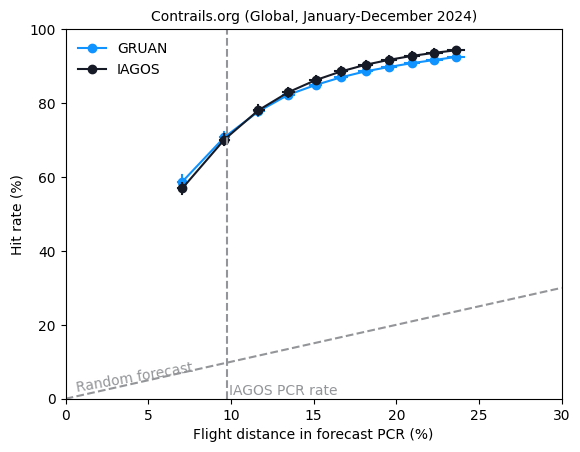

In [16]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, January-December 2024)", fontsize=10)

plt.savefig("figures/global-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-contrails-org.png", dpi=300, bbox_inches="tight");

## Google

#### Final processing + bootstrapping

In [17]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos")
df_gruan = open_dfs("google-gruan")

google-adsb:   0%|          | 0/8712 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/8712 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/8712 [00:00<?, ?it/s]

In [18]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "probability_threshold"),
        "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
        "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    }
)

In [19]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "probability_threshold"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos,
    df_iagos["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)
gruan_ci = bootstrap(
    df_gruan,
    df_gruan["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/363 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/363 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/363 [00:00<?, ?it/s]

In [20]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [21]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-google.pq")

In [22]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-google-ci.pq")

#### Plot

In [23]:
df = pd.read_parquet("gs://contrailbench-public-data/v1/benchmarks/global-google.pq")
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-google-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

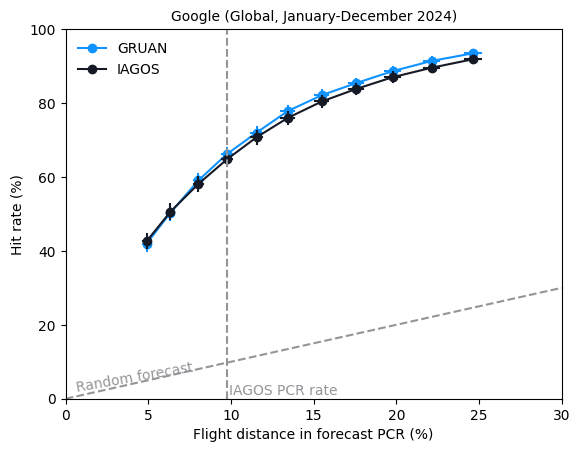

In [24]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (Global, January-December 2024)", fontsize=10)

plt.savefig("figures/global-google.pdf", bbox_inches="tight")
plt.savefig("figures/global-google.png", dpi=300, bbox_inches="tight");

# Global (January/February/December 2024)

## Contrails.org

#### Final processing + bootstrapping

In [25]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [26]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.isin([1, 2, 12])]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.isin([1, 2, 12])]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.isin([1, 2, 12])]

In [27]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "horizontal_buffer"),
        "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
        "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    }
)

In [28]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)
gruan_ci = bootstrap(
    df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

In [29]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [30]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-winter-contrails-org.pq")

In [31]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-winter-contrails-org-ci.pq")

#### Plot

In [32]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-winter-contrails-org.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-winter-contrails-org-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([1, 2, 12])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

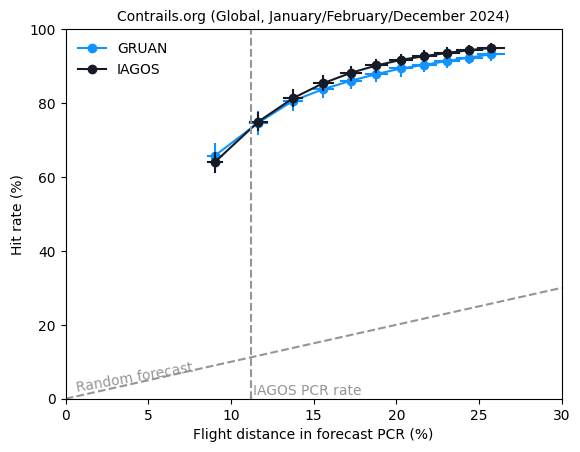

In [33]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, January/February/December 2024)", fontsize=10)

plt.savefig("figures/global-winter-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-winter-contrails-org.png", dpi=300, bbox_inches="tight");

## Google

#### Final processing + bootstrapping

In [34]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos")
df_gruan = open_dfs("google-gruan")

google-adsb:   0%|          | 0/8712 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/8712 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/8712 [00:00<?, ?it/s]

In [35]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.isin([1, 2, 12])]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.isin([1, 2, 12])]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.isin([1, 2, 12])]

In [36]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "probability_threshold"),
        "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
        "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    }
)

In [37]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "probability_threshold"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos,
    df_iagos["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)
gruan_ci = bootstrap(
    df_gruan,
    df_gruan["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

In [38]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [39]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-winter-google.pq")

In [40]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-winter-google-ci.pq")

#### Plot

In [41]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-winter-google.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-winter-google-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([1, 2, 12])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

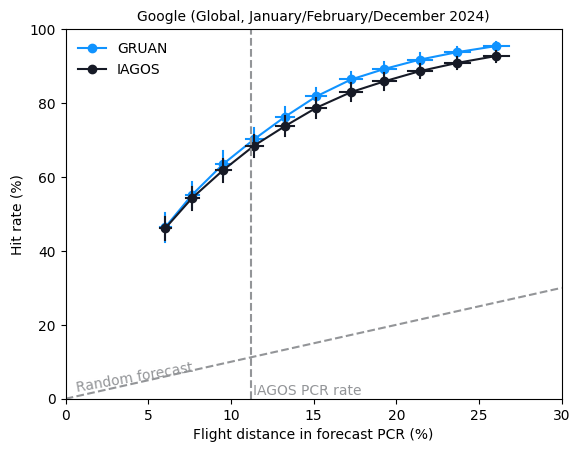

In [42]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (Global, January/February/December 2024)", fontsize=10)

plt.savefig("figures/global-winter-google.pdf", bbox_inches="tight")
plt.savefig("figures/global-winter-google.png", dpi=300, bbox_inches="tight");

# Global (March-May 2024)

## Contrails.org

#### Final processing + bootstrapping

In [43]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [44]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(3, 5)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(3, 5)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(3, 5)]

In [45]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "horizontal_buffer"),
        "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
        "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    }
)

In [46]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)
gruan_ci = bootstrap(
    df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

In [47]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [48]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-spring-contrails-org.pq")

In [49]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-spring-contrails-org-ci.pq")

#### Plot

In [50]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-spring-contrails-org.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-spring-contrails-org-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([3, 4, 5])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

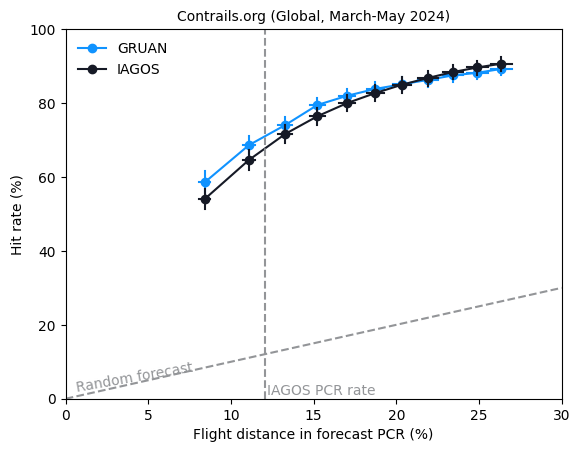

In [51]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, March-May 2024)", fontsize=10)

plt.savefig("figures/global-spring-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-spring-contrails-org.png", dpi=300, bbox_inches="tight");

## Google

#### Final processing + bootstrapping

In [52]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos")
df_gruan = open_dfs("google-gruan")

google-adsb:   0%|          | 0/8712 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/8712 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/8712 [00:00<?, ?it/s]

In [53]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(3, 5)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(3, 5)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(3, 5)]

In [54]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "probability_threshold"),
        "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
        "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    }
)

In [55]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "probability_threshold"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos,
    df_iagos["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)
gruan_ci = bootstrap(
    df_gruan,
    df_gruan["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/90 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/90 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/90 [00:00<?, ?it/s]

In [56]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [57]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-spring-google.pq")

In [58]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-spring-google-ci.pq")

#### Plot

In [59]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-spring-google.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-spring-google-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([3, 4, 5])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

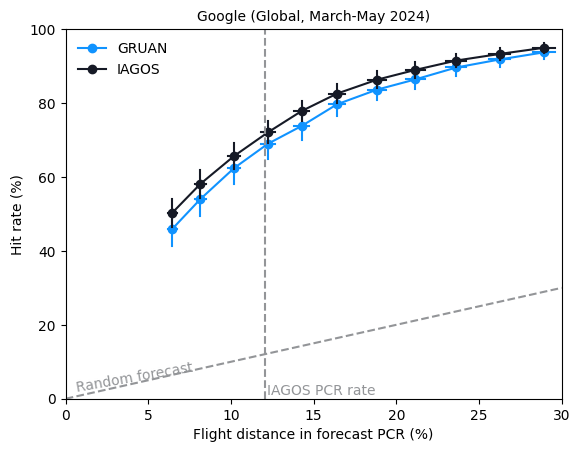

In [60]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (Global, March-May 2024)", fontsize=10)

plt.savefig("figures/global-spring-google.pdf", bbox_inches="tight")
plt.savefig("figures/global-spring-google.png", dpi=300, bbox_inches="tight");

# Global (June-August 2024)

## Contrails.org

#### Final processing + bootstrapping

In [61]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [62]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(6, 8)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(6, 8)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(6, 8)]

In [63]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "horizontal_buffer"),
        "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
        "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    }
)

In [64]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)
gruan_ci = bootstrap(
    df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

In [65]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [66]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-summer-contrails-org.pq")

In [67]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-summer-contrails-org-ci.pq")

#### Plot

In [68]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-summer-contrails-org.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-summer-contrails-org-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([6, 7, 8])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

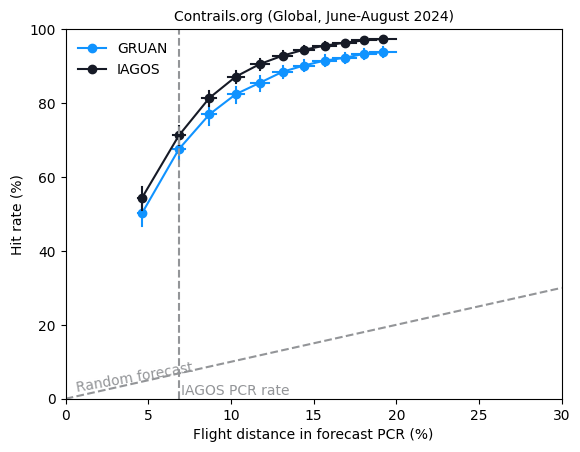

In [69]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, June-August 2024)", fontsize=10)

plt.savefig("figures/global-summer-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-summer-contrails-org.png", dpi=300, bbox_inches="tight");

## Google

#### Final processing + bootstrapping

In [70]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos")
df_gruan = open_dfs("google-gruan")

google-adsb:   0%|          | 0/8712 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/8712 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/8712 [00:00<?, ?it/s]

In [71]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(6, 8)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(6, 8)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(6, 8)]

In [72]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "probability_threshold"),
        "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
        "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    }
)

In [73]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "probability_threshold"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos,
    df_iagos["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)
gruan_ci = bootstrap(
    df_gruan,
    df_gruan["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

In [74]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [75]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-summer-google.pq")

In [76]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-summer-google-ci.pq")

#### Plot

In [77]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-summer-google.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-summer-google-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([6, 7, 8])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

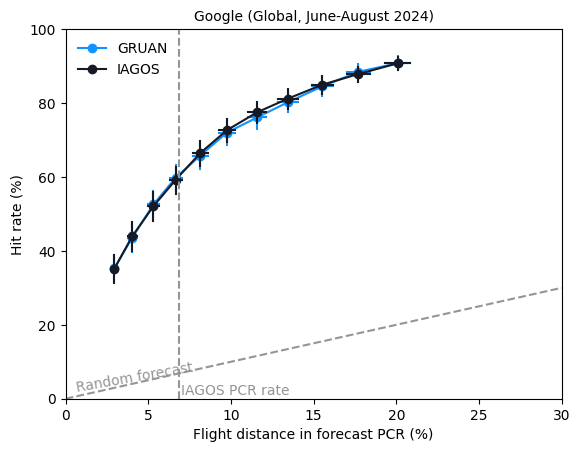

In [78]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (Global, June-August 2024)", fontsize=10)

plt.savefig("figures/global-summer-google.pdf", bbox_inches="tight")
plt.savefig("figures/global-summer-google.png", dpi=300, bbox_inches="tight");

# Global (September-November 2024)

## Contrails.org

#### Final processing + bootstrapping

In [79]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [80]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(9, 11)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(9, 11)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(9, 11)]

In [81]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "horizontal_buffer"),
        "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
        "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    }
)

In [82]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)
gruan_ci = bootstrap(
    df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

In [83]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [84]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-autumn-contrails-org.pq")

In [85]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-autumn-contrails-org-ci.pq")

#### Plot

In [86]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-autumn-contrails-org.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-autumn-contrails-org-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([9, 10, 11])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

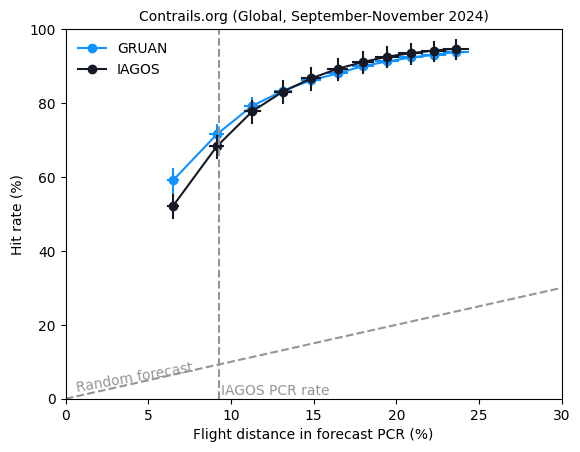

In [87]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, September-November 2024)", fontsize=10)

plt.savefig("figures/global-autumn-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-autumn-contrails-org.png", dpi=300, bbox_inches="tight");

## Google

#### Final processing + bootstrapping

In [88]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos")
df_gruan = open_dfs("google-gruan")

google-adsb:   0%|          | 0/8712 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/8712 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/8712 [00:00<?, ?it/s]

In [89]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(9, 11)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(9, 11)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(9, 11)]

In [90]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "probability_threshold"),
        "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
        "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    }
)

In [91]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "probability_threshold"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos,
    df_iagos["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)
gruan_ci = bootstrap(
    df_gruan,
    df_gruan["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

In [92]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
    }
)

In [93]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-autumn-google.pq")

In [94]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/global-autumn-google-ci.pq")

#### Plot

In [95]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-autumn-google.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/global-autumn-google-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([9, 10, 11])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

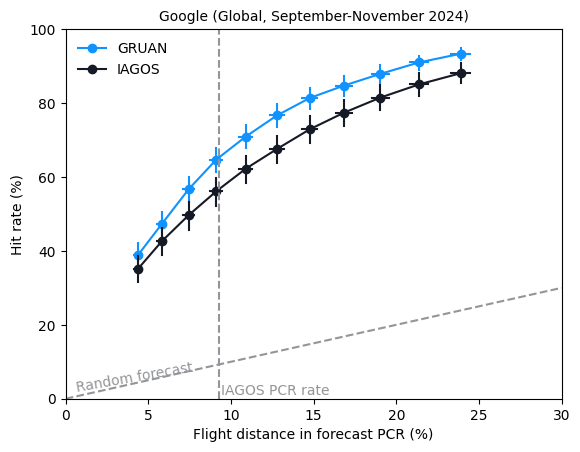

In [96]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (Global, September-November 2024)", fontsize=10)

plt.savefig("figures/global-autumn-google.pdf", bbox_inches="tight")
plt.savefig("figures/global-autumn-google.png", dpi=300, bbox_inches="tight");

# CONUS (January-December 2024)

## Contrails.org

#### Final processing + bootstrapping

In [97]:
df_adsb = open_dfs("contrails-org-adsb-contrailwatch-region")
df_iagos = open_dfs("contrails-org-iagos-contrailwatch-region")
df_gruan = open_dfs("contrails-org-gruan-contrailwatch-region")
df_contrailwatch = open_dfs("contrails-org-contrailwatch-contrailwatch-region")

contrails-org-adsb-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

In [98]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "horizontal_buffer"),
        "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
        "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
        "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
    }
)

In [99]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)
gruan_ci = bootstrap(
    df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng
)
contrailwatch_ci = bootstrap(
    df_contrailwatch,
    df_contrailwatch["time"].dt.date,
    n,
    lambda df: hit_rate(df, "horizontal_buffer"),
    0.05,
    rng,
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

In [100]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
        "contrailwatch_hit_rate_lo": contrailwatch_ci.iloc[:, 0],
        "contrailwatch_hit_rate_hi": contrailwatch_ci.iloc[:, 1],
    }
)

In [101]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/conus-contrails-org.pq")

In [102]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/conus-contrails-org-ci.pq")

#### Plot

In [103]:
df = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/conus-contrails-org.pq"
)
df_ci = pd.read_parquet(
    "gs://contrailbench-public-data/v1/benchmarks/conus-contrails-org-ci.pq"
)
iagos_daily = pd.read_parquet("data/iagos-statistics/daily-contrailwatch.pq")
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

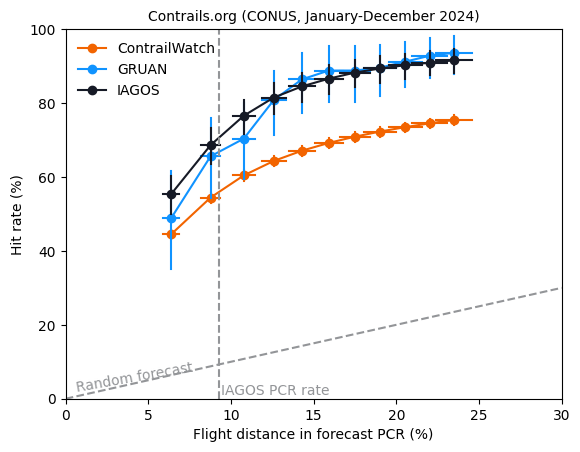

In [104]:
plt.plot(
    100 * df["penalty"],
    100 * df["contrailwatch_hit_rate"],
    "o-",
    color=solar_orange,
    label="ContrailWatch",
)
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["contrailwatch_hit_rate", "contrailwatch_hit_rate"]].T,
    "-",
    color=solar_orange,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["contrailwatch_hit_rate_lo", "contrailwatch_hit_rate_hi"]].T,
    "-",
    color=solar_orange,
)

plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (CONUS, January-December 2024)", fontsize=10)

plt.savefig("figures/conus-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/conus-contrails-org.png", dpi=300, bbox_inches="tight");

## Google

#### Final processing + bootstrapping

In [105]:
df_adsb = open_dfs("google-adsb-contrailwatch-region")
df_iagos = open_dfs("google-iagos-contrailwatch-region")
df_gruan = open_dfs("google-gruan-contrailwatch-region")
df_contrailwatch = open_dfs("google-contrailwatch-contrailwatch-region")

google-adsb-contrailwatch-region:   0%|          | 0/8712 [00:00<?, ?it/s]

google-iagos-contrailwatch-region:   0%|          | 0/8712 [00:00<?, ?it/s]

google-gruan-contrailwatch-region:   0%|          | 0/8712 [00:00<?, ?it/s]

google-contrailwatch-contrailwatch-region:   0%|          | 0/8712 [00:00<?, ?it/s]

In [106]:
df = pd.DataFrame(
    {
        "penalty": penalty(df_adsb, "probability_threshold"),
        "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
        "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
        "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "probability_threshold"),
    }
)

In [107]:
rng = np.random.default_rng(301217)
n = 10_000
penalty_ci = bootstrap(
    df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "probability_threshold"), 0.05, rng
)
iagos_ci = bootstrap(
    df_iagos,
    df_iagos["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)
gruan_ci = bootstrap(
    df_gruan,
    df_gruan["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)
contrailwatch_ci = bootstrap(
    df_contrailwatch,
    df_contrailwatch["time"].dt.date,
    n,
    lambda df: hit_rate(df, "probability_threshold"),
    0.05,
    rng,
)

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/363 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/363 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/363 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/10000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/363 [00:00<?, ?it/s]

In [108]:
df_ci = pd.DataFrame(
    {
        "penalty_lo": penalty_ci.iloc[:, 0],
        "penalty_hi": penalty_ci.iloc[:, 1],
        "iagos_hit_rate_lo": iagos_ci.iloc[:, 0],
        "iagos_hit_rate_hi": iagos_ci.iloc[:, 1],
        "gruan_hit_rate_lo": gruan_ci.iloc[:, 0],
        "gruan_hit_rate_hi": gruan_ci.iloc[:, 1],
        "contrailwatch_hit_rate_lo": contrailwatch_ci.iloc[:, 0],
        "contrailwatch_hit_rate_hi": contrailwatch_ci.iloc[:, 1],
    }
)

In [109]:
# df.to_parquet("gs://contrailbench-public-data/v1/benchmarks/conus-google.pq")

In [110]:
# df_ci.to_parquet("gs://contrailbench-public-data/v1/benchmarks/conus-google-ci.pq")

#### Plot

In [111]:
df = pd.read_parquet("gs://contrailbench-public-data/v1/benchmarks/conus-google.pq")
df_ci = pd.read_parquet("gs://contrailbench-public-data/v1/benchmarks/conus-google-ci.pq")
iagos_daily = pd.read_parquet("data/iagos-statistics/daily-contrailwatch.pq")
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

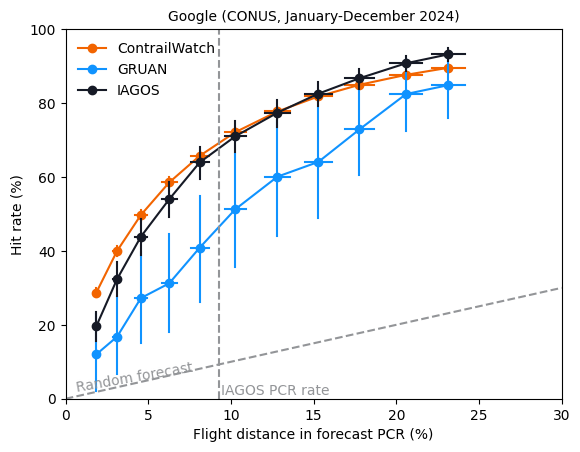

In [112]:
plt.plot(
    100 * df["penalty"],
    100 * df["contrailwatch_hit_rate"],
    "o-",
    color=solar_orange,
    label="ContrailWatch",
)
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["contrailwatch_hit_rate", "contrailwatch_hit_rate"]].T,
    "-",
    color=solar_orange,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["contrailwatch_hit_rate_lo", "contrailwatch_hit_rate_hi"]].T,
    "-",
    color=solar_orange,
)

plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T,
    "-",
    color=tropo_blue,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T,
    "-",
    color=tropo_blue,
)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(
    100 * df_ci[["penalty_lo", "penalty_hi"]].T,
    100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T,
    "-",
    color=exo_black,
)
plt.plot(
    100 * df[["penalty", "penalty"]].T,
    100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T,
    "-",
    color=exo_black,
)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 30])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate(
    "Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10
)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (CONUS, January-December 2024)", fontsize=10)

plt.savefig("figures/conus-google.pdf", bbox_inches="tight")
plt.savefig("figures/conus-google.png", dpi=300, bbox_inches="tight");